Train R²: 0.9684
Test R²: 0.9792
Train MSE: 0.0158
Test MSE: 0.0068
Train MAE: 0.0889
Test MAE: 0.0630

散点图已保存为：/home/ggx/wls/DAC-code/co/UL/ST/ST-AdaBoost/5000/regression_results.png

散点图的数据已保存为：/home/ggx/wls/DAC-code/co/UL/ST/ST-AdaBoost/5000/scatter_plot_data.xlsx


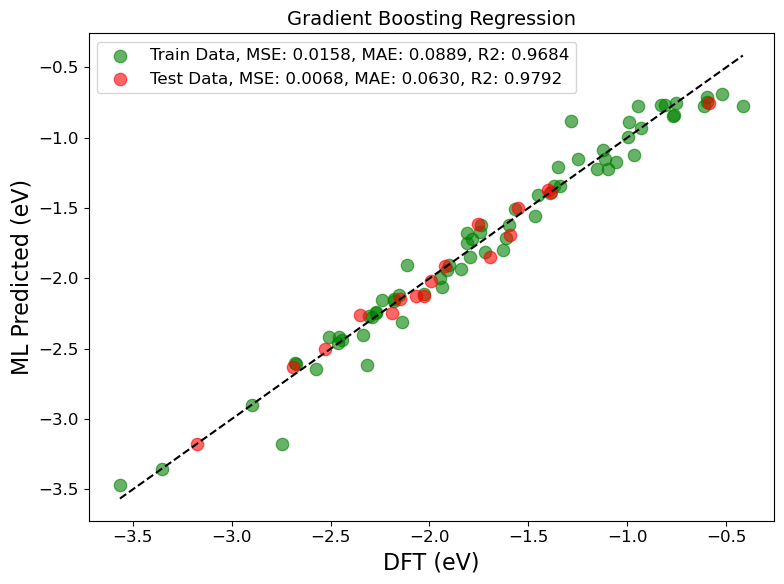

In [5]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import joblib  # 用于加载保存的模型
import matplotlib.pyplot as plt

# 设置全局字体大小
plt.rcParams.update({'font.size': 12})  # 设置全局字体大小为12

# 从Excel文件中读取数据
data = pd.read_excel('/home/ggx/wls/DAC-code/co/UL/ST/data/ST-5-XGBR-UL-CO-sol.xlsx')

X = data.iloc[:, 1:-1].to_numpy()  # Features (all columns except first and last)
y = data.iloc[:, -1]  # Target (last column)

# 加载保存的最佳模型和Scaler
best_model_filename = '/home/ggx/wls/DAC-code/co/UL/ST/ST-AdaBoost/5000/best_model.pkl'
best_scaler_filename = '/home/ggx/wls/DAC-code/co/UL/ST/ST-AdaBoost/5000/best_scaler.pkl'

best_model = joblib.load(best_model_filename)
best_scaler = joblib.load(best_scaler_filename)

# 分割数据集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 使用加载的Scaler对数据进行归一化
X_train_normalized = best_scaler.transform(X_train)
X_test_normalized = best_scaler.transform(X_test)

# 使用加载的模型进行预测
pred_train = best_model.predict(X_train_normalized)
pred_test = best_model.predict(X_test_normalized)

# 计算评估指标
train_r2 = r2_score(y_train, pred_train)
test_r2 = r2_score(y_test, pred_test)
train_mse = mean_squared_error(y_train, pred_train)
test_mse = mean_squared_error(y_test, pred_test)
train_mae = mean_absolute_error(y_train, pred_train)
test_mae = mean_absolute_error(y_test, pred_test)

# 打印评估指标
print(f"Train R²: {train_r2:.4f}")
print(f"Test R²: {test_r2:.4f}")
print(f"Train MSE: {train_mse:.4f}")
print(f"Test MSE: {test_mse:.4f}")
print(f"Train MAE: {train_mae:.4f}")
print(f"Test MAE: {test_mae:.4f}")

# 可视化结果
plt.figure(figsize=(8, 6))
plt.scatter(y_train, pred_train, label=f'Train Data, MSE: {train_mse:.4f}, MAE: {train_mae:.4f}, R2: {train_r2:.4f}', color="green", alpha=0.6, s=80, linewidth=0.9)
plt.scatter(y_test, pred_test, label=f'Test Data, MSE: {test_mse:.4f}, MAE: {test_mae:.4f}, R2: {test_r2:.4f}', color="red", alpha=0.6, s=80, linewidth=0.9)
plt.plot([min(y), max(y)], [min(y), max(y)], linestyle="--", color="black")

# 设置标题和标签的字体大小
plt.title("Gradient Boosting Regression", fontsize=14)  # 标题字体大小
plt.xlabel("DFT (eV)", fontsize=16)  # x轴标签字体大小
plt.ylabel("ML Predicted (eV)", fontsize=16)  # y轴标签字体大小

# 设置图例的字体大小
plt.legend(fontsize=12)

plt.tight_layout()

# 保存散点图到当前文件夹
current_directory = os.getcwd()  # 获取当前工作目录
scatter_plot_filename = os.path.join(current_directory, "regression_results.png")
plt.savefig(scatter_plot_filename)  # 保存图像
print(f"\n散点图已保存为：{scatter_plot_filename}")

# 输出散点图的数据到Excel
# 创建一个新的DataFrame，包含训练集和测试集的真实值和预测值
train_data = pd.DataFrame({'Dataset': 'Train', 'DFT (eV)': y_train, 'ML Predicted (eV)': pred_train})
test_data = pd.DataFrame({'Dataset': 'Test', 'DFT (eV)': y_test, 'ML Predicted (eV)': pred_test})

# 合并训练集和测试集的数据
combined_data = pd.concat([train_data, test_data], ignore_index=True)

# 保存到Excel文件
scatter_data_excel_filename = os.path.join(current_directory, "scatter_plot_data.xlsx")
combined_data.to_excel(scatter_data_excel_filename, index=False)
print(f"\n散点图的数据已保存为：{scatter_data_excel_filename}")

In [4]:
plt.show()

# 使用SHAP进行特征重要性分析
explainer = shap.Explainer(best_model)
shap_values = explainer(X_test_normalized)

# 绘制SHAP总结图
shap.summary_plot(shap_values, X_test_normalized, feature_names=data.columns[1:-1])

# 保存SHAP图到当前文件夹
shap_plot_filename = os.path.join(current_directory, "shap_summary.png")
plt.savefig(shap_plot_filename)
print(f"\nSHAP图已保存为：{shap_plot_filename}")

plt.show()

TypeError: The passed model is not callable and cannot be analyzed directly with the given masker! Model: AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=29,
                                                  min_samples_leaf=2),
                  learning_rate=0.5, n_estimators=2000)